<a href="https://colab.research.google.com/github/evellynjardini/Data-Analytics---Grupo-24/blob/main/1%20-%20Projeto-Olist-KPIs/notebooks/Receita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import pandas as pd

# Monta o seu Google Drive
drive.mount('/content/drive')

# Carrega a base consolidada
caminho_arquivo = '/content/drive/MyDrive/df_consolidado.csv'
df_consolidado = pd.read_csv(caminho_arquivo)

df_consolidado.head()

Mounted at /content/drive


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,...,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_city_clean,seller_zip_code_prefix,seller_city,seller_state,atrasado
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,...,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,Sao Paulo,9350.0,Maua,SP,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,...,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,Barreiras,31570.0,Belo Horizonte,SP,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,...,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,Vianopolis,14840.0,Guariba,SP,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,...,pet_shop,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,Sao Goncalo Do Amarante,31842.0,Belo Horizonte,MG,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,...,stationery,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,Santo Andre,8752.0,Mogi Das Cruzes,SP,False


In [2]:
df_consolidado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   price                          98666 non-null  float64
 9   freight_value                  98666 non-null  float64
 10  product_id                     98666 non-null  object 
 11  seller_id                      98666 non-null  object 
 12  payment_value                  99440 non-null 

In [3]:
# --- KPI 1: Receita Total ao Longo do Tempo (Mensal) ---

# 1. Filtramos apenas os pedidos entregues diretamente da base consolidada
# (Isso garante que estamos olhando para receita confirmada)
df_receita = df_consolidado[df_consolidado['order_status'] == 'delivered'].copy()

# 2. Garantimos que a coluna de data esteja no formato correto e criamos o Ano-Mês
df_receita['order_purchase_timestamp'] = pd.to_datetime(df_receita['order_purchase_timestamp'])
df_receita['ano_mes'] = df_receita['order_purchase_timestamp'].dt.to_period('M')

# Excluindo o ano de 2016
df_receita = df_receita[df_receita['order_purchase_timestamp'].dt.year != 2016]

# 3. Agregamos a receita (payment_value) e a quantidade por mês
# Como a base é única por pedido, o count('order_id') é exato.
tabela_receita_mensal = (
    df_receita
    .groupby('ano_mes', as_index=False)
    .agg(
        receita_total=('payment_value', 'sum'),
        qtd_pedidos=('order_id', 'count')
    )
    .sort_values('ano_mes')
)

# --- RESULTADOS ---
print(f"{'='*20} KPI 1: RECEITA MENSAL {'='*20}")
print(f"Período: {tabela_receita_mensal['ano_mes'].min()} a {tabela_receita_mensal['ano_mes'].max()}")
print(f"Receita Total (Pedidos Entregues): R$ {df_receita['payment_value'].sum():,.2f}")
print(f"Ticket Médio Mensal: R$ {(df_receita['payment_value'].sum() / df_receita['order_id'].nunique()):,.2f}")
print(f"{'='*53}")

tabela_receita_mensal.head(10)

==================== KPI 1: RECEITA MENSAL ====================
Período: 2017-01 a 2018-08
Receita Total (Pedidos Entregues): R$ 15,375,875.44
Ticket Médio Mensal: R$ 159.81


,ano_mes,receita_total,qtd_pedidos
0,2017-01,127545.67,750
1,2017-02,271298.65,1653
2,2017-03,414369.39,2546
3,2017-04,390952.18,2303
4,2017-05,567066.73,3546
5,2017-06,490225.60,3135
6,2017-07,566403.93,3872
7,2017-08,646000.61,4193
8,2017-09,701169.99,4150
9,2017-10,751140.27,4478


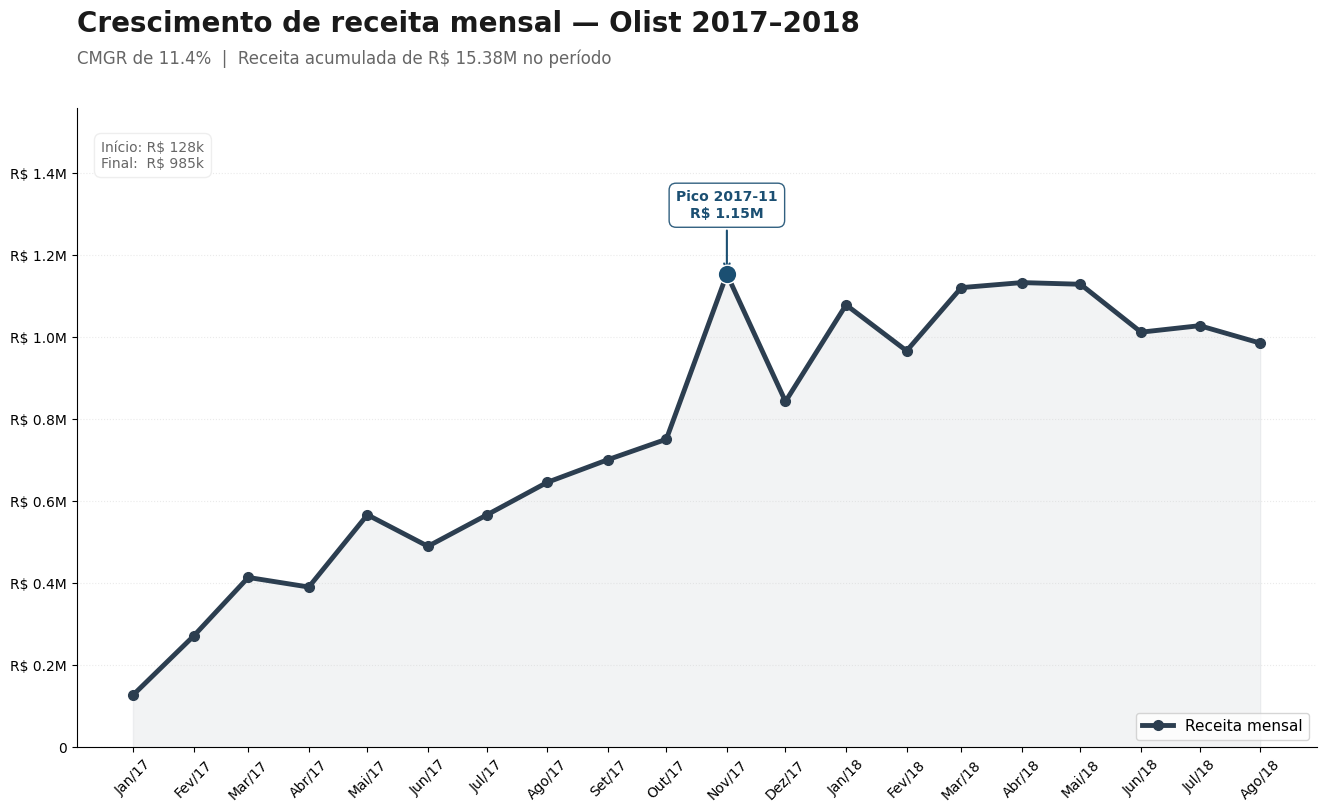

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# --- Preparo dos dados ---
df_plot = (
    tabela_receita_mensal
    .copy()
    .loc[tabela_receita_mensal['ano_mes'].astype(str) >= '2017-01']
    .reset_index(drop=True)
)
df_plot['data'] = pd.to_datetime(df_plot['ano_mes'].astype(str))

# --- Métricas ---
val_inicial   = df_plot['receita_total'].iloc[0]
val_final     = df_plot['receita_total'].iloc[-1]
multiplo      = val_final / val_inicial
n_meses       = len(df_plot) - 1
cmgr          = (multiplo) ** (1 / n_meses) - 1
receita_total = df_plot['receita_total'].sum()

# Pico
idx_pico  = df_plot['receita_total'].idxmax()
data_pico = df_plot.loc[idx_pico, 'data']
val_pico  = df_plot.loc[idx_pico, 'receita_total']
mes_pico  = df_plot.loc[idx_pico, 'ano_mes']

# --- Cores ---
AZUL_ESCURO = '#2c3e50'
CINZA_TEXTO = '#1A1A1A'
CINZA_SUB   = '#666666'
COR_PICO    = '#1b4f72'

# --- Visualização ---
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')

# --- Caixa de resumo ---
info_box = f"Início: R$ {val_inicial/1_000:.0f}k\nFinal:  R$ {val_final/1_000:.0f}k"
ax.text(
    0.02, 0.95, info_box, transform=ax.transAxes, fontsize=10,
    bbox=dict(facecolor='white', edgecolor='#eeeeee', boxstyle='round,pad=0.5'),
    color=CINZA_SUB, va='top', zorder=10
)

# --- Linha de receita ---
ax.plot(
    df_plot['data'], df_plot['receita_total'],
    color=AZUL_ESCURO, lw=3.5, marker='o', markersize=7,
    label='Receita mensal', zorder=4
)
ax.fill_between(df_plot['data'], df_plot['receita_total'], alpha=0.06, color=AZUL_ESCURO)

# --- Anotação de pico ---
ax.scatter(data_pico, val_pico, color=COR_PICO, s=180, zorder=5, edgecolor='white')
ax.annotate(
    f'Pico {mes_pico}\nR$ {val_pico/1e6:.2f}M',
    xy=(data_pico, val_pico),
    xytext=(data_pico, val_pico * 1.12),
    arrowprops=dict(arrowstyle='->', color=COR_PICO, lw=1.5),
    ha='center', fontweight='bold', color=COR_PICO,
    bbox=dict(boxstyle='round,pad=0.5', fc='white', ec=COR_PICO, alpha=0.9)
)

# --- Eixos ---
meses_pt = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(
    lambda x, p: f"{meses_pt[mdates.num2date(x).month-1]}/{str(mdates.num2date(x).year)[2:]}"
))
ax.yaxis.set_major_formatter(FuncFormatter(
    lambda x, p: f'R$ {x/1e6:.1f}M' if x > 0 else '0'
))
plt.xticks(rotation=45)
ax.set_ylim(0, val_pico * 1.35)

# --- Títulos à esquerda ---
ax.text(
    0, 1.12,
    'Crescimento de receita mensal — Olist 2017–2018',
    transform=ax.transAxes, fontsize=20, fontweight='bold',
    color=CINZA_TEXTO, ha='left'
)

ax.text(
    0, 1.07,
    f'CMGR de {cmgr*100:.1f}%  |  Receita acumulada de R$ {receita_total/1e6:.2f}M no período',
    transform=ax.transAxes, fontsize=12, color=CINZA_SUB, ha='left'
)

ax.legend(loc='lower right', frameon=True, facecolor='white', fontsize=11)
plt.subplots_adjust(top=0.82)
plt.show()

In [5]:
# --- KPI 2: Ticket Médio ao Longo do Tempo (Mensal) ---

# 1. Utilizamos a tabela_receita_mensal já calculado no KPI receita mensal

# 2. Calculamos o ticket médio mensal (Receita / Quantidade de Pedidos)
tabela_receita_mensal['ticket_medio'] = tabela_receita_mensal['receita_total'] / tabela_receita_mensal['qtd_pedidos']

# --- RESULTADOS ---
print(f"{'='*20} KPI 2: TICKET MÉDIO {'='*20}")

# Calculamos a média real baseada no total de pedidos entregues do df_receita
ticket_medio_geral = df_receita['payment_value'].sum() / df_receita['order_id'].nunique()

print(f"Ticket médio geral (Período Total): R$ {ticket_medio_geral:,.2f}")
print(f"{'='*53}")

# Exibindo as colunas principais
tabela_receita_mensal[['ano_mes', 'qtd_pedidos', 'receita_total', 'ticket_medio']].head(10)

==================== KPI 2: TICKET MÉDIO ====================
Ticket médio geral (Período Total): R$ 159.81


,ano_mes,qtd_pedidos,receita_total,ticket_medio
0,2017-01,750,127545.67,170.060893
1,2017-02,1653,271298.65,164.125015
2,2017-03,2546,414369.39,162.753099
3,2017-04,2303,390952.18,169.757785
4,2017-05,3546,567066.73,159.917296
5,2017-06,3135,490225.60,156.371802
6,2017-07,3872,566403.93,146.282007
7,2017-08,4193,646000.61,154.066446
8,2017-09,4150,701169.99,168.956624
9,2017-10,4478,751140.27,167.740123


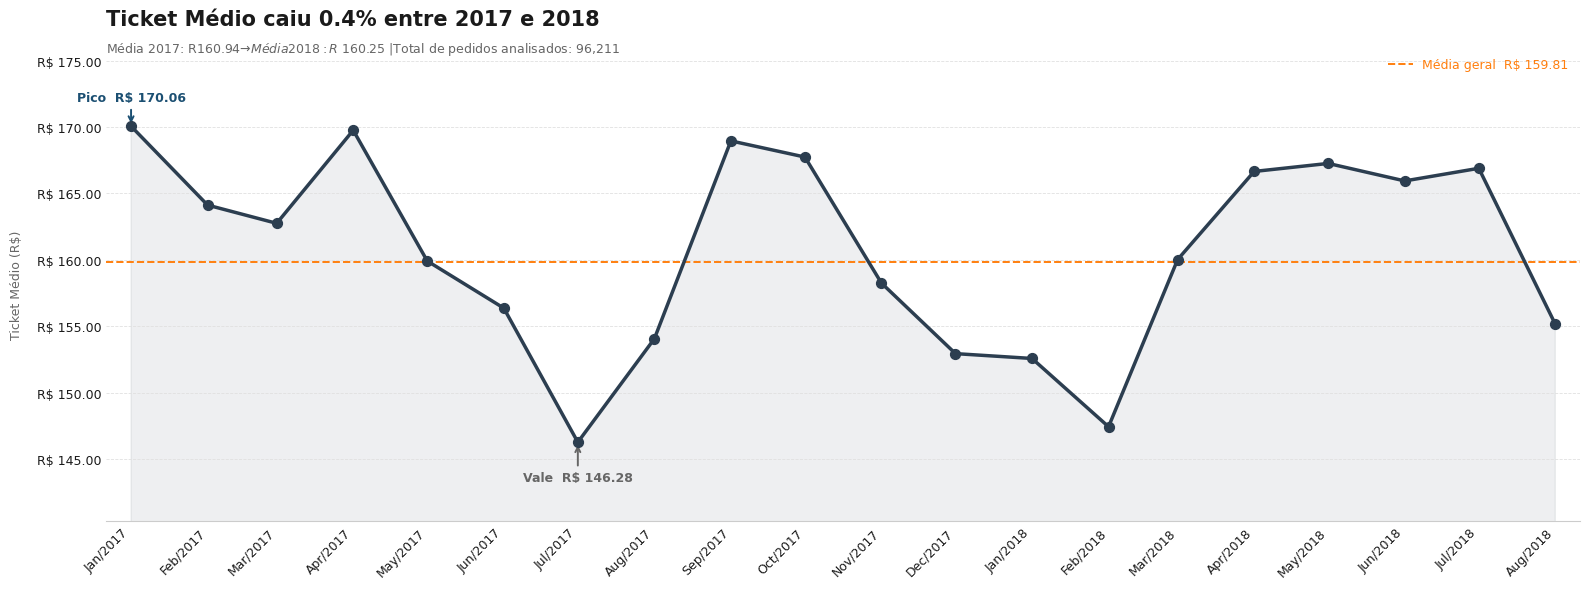

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Paleta ────────────────────────────────────────────────────────────────────
AZUL_ESCURO = '#2c3e50'
CINZA_TEXTO = '#1A1A1A'
CINZA_SUB   = '#666666'
COR_PICO    = '#1b4f72'
LARANJA     = '#ff7f0e'

# ── Preparação dos dados ───────────────────────────────────────────────────────
df_plot = tabela_receita_mensal.copy()
df_plot['ano_mes_dt'] = df_plot['ano_mes'].dt.to_timestamp()

idx_pico = df_plot['ticket_medio'].idxmax()
idx_vale = df_plot['ticket_medio'].idxmin()

# ── Cálculo do insight para o título ──────────────────────────────────────────
ticket_2017 = df_plot[df_plot['ano_mes_dt'].dt.year == 2017]['ticket_medio'].mean()
ticket_2018 = df_plot[df_plot['ano_mes_dt'].dt.year == 2018]['ticket_medio'].mean()
variacao_pct = ((ticket_2018 - ticket_2017) / ticket_2017) * 100
direcao = "cresceu" if variacao_pct > 0 else "caiu"
total_pedidos= df_plot['qtd_pedidos'].sum()
# ── Canvas ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Linha principal
ax.plot(
    df_plot['ano_mes_dt'],
    df_plot['ticket_medio'],
    color=AZUL_ESCURO,
    linewidth=2.5,
    zorder=3,
)

# Marcadores
ax.scatter(
    df_plot['ano_mes_dt'],
    df_plot['ticket_medio'],
    color=AZUL_ESCURO,
    s=50,
    zorder=4,
)

# Linha de média tracejada em LARANJA
ax.axhline(
    ticket_medio_geral,
    color=LARANJA,
    linewidth=1.4,
    linestyle='--',
    zorder=2,
    label=f'Média geral  R$ {ticket_medio_geral:,.2f}',
)

# Área sob a curva
ax.fill_between(
    df_plot['ano_mes_dt'],
    df_plot['ticket_medio'],
    alpha=0.08,
    color=AZUL_ESCURO,
)

# ── Anotação Pico ──────────────────────────────────────────────────────────────
ax.annotate(
    f"Pico  R$ {df_plot.loc[idx_pico, 'ticket_medio']:,.2f}",
    xy=(df_plot.loc[idx_pico, 'ano_mes_dt'], df_plot.loc[idx_pico, 'ticket_medio']),
    xytext=(0, 18),
    textcoords='offset points',
    ha='center',
    fontsize=9,
    fontweight='bold',
    color=COR_PICO,
    arrowprops=dict(arrowstyle='->', color=COR_PICO, lw=1.4),
)

# ── Anotação Vale ──────────────────────────────────────────────────────────────
ax.annotate(
    f"Vale  R$ {df_plot.loc[idx_vale, 'ticket_medio']:,.2f}",
    xy=(df_plot.loc[idx_vale, 'ano_mes_dt'], df_plot.loc[idx_vale, 'ticket_medio']),
    xytext=(0, -28),
    textcoords='offset points',
    ha='center',
    fontsize=9,
    fontweight='bold',
    color=CINZA_SUB,
    arrowprops=dict(arrowstyle='->', color=CINZA_SUB, lw=1.4),
)

# ── Eixos ──────────────────────────────────────────────────────────────────────
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.2f}'))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=1))

plt.xticks(rotation=45, ha='right', fontsize=9, color=CINZA_TEXTO)
plt.yticks(fontsize=9, color=CINZA_TEXTO)

# Limites Y com respiro
margem = (df_plot['ticket_medio'].max() - df_plot['ticket_medio'].min()) * 0.25
ax.set_ylim(
    df_plot['ticket_medio'].min() - margem,
    df_plot['ticket_medio'].max() + margem,
)

# Limites X com respiro lateral
ax.set_xlim(
    df_plot['ano_mes_dt'].min() - pd.DateOffset(days=10),
    df_plot['ano_mes_dt'].max() + pd.DateOffset(days=10),
)

# ── Grid leve ─────────────────────────────────────────────────────────────────
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, color='#e0e0e0', zorder=1)
ax.xaxis.grid(False)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='both', length=0)

# ── Títulos com insight dinâmico ───────────────────────────────────────────────
ax.set_title(
    f'Ticket Médio {direcao} {abs(variacao_pct):.1f}% entre 2017 e 2018',
    fontsize=15,
    fontweight='bold',
    color=CINZA_TEXTO,
    pad=16,
    loc='left',
)
ax.text(
    0, 0.98,
    f'Média 2017: R$ {ticket_2017:,.2f}  →  Média 2018: R$ {ticket_2018:,.2f} |'
    f'Total de pedidos analisados: {total_pedidos:,.0f}',
    transform=ax.transAxes,
    fontsize=9,
    color=CINZA_SUB,
    va='bottom',

)


ax.set_xlabel('')
ax.set_ylabel('Ticket Médio (R$)', fontsize=9, color=CINZA_SUB, labelpad=10)

ax.legend(
    fontsize=9,
    frameon=False,
    loc='upper right',
    labelcolor=LARANJA,
)

plt.tight_layout()
plt.savefig('ticket_medio_olist.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
from google.colab import files

df_receita.to_excel('df_receita.xlsx', index=False)

files.download('df_receita.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# --- KPI 3: Receita por Categoria ---

# 1. Base usada nos indicadores anteriores de Receita

# 2. Tratamos categorias ausentes (Data Cleaning dentro do KPI)
# Usaremos 'product_category_name_english' que é o nome comum após a tradução
col_categoria = 'product_category_clean'

if col_categoria in df_receita.columns:
    df_receita[col_categoria] = df_receita[col_categoria].fillna('sem_categoria')
else:
    # Caso sua coluna tenha outro nome, como 'product_category_name'
    col_categoria = 'product_category_name'
    df_receita[col_categoria] = df_receita[col_categoria].fillna('sem_categoria')

# 3. Agregamos os valores por categoria
# Como a base é consolidada por pedido, price e freight_value já são os totais do pedido
tabela_receita_por_categoria = (
    df_receita
    .groupby(col_categoria, as_index=False)
    .agg(
        receita_produtos=('price', 'sum'),
        receita_frete=('freight_value', 'sum'),
        qtd_pedidos=('order_id', 'count') # Cada linha é um pedido único
    )
    .assign(receita_total=lambda x: x['receita_produtos'] + x['receita_frete'])
    .sort_values('receita_produtos', ascending=False)
    .reset_index(drop=True)
)

# --- RESULTADOS ---
print(f"{'='*20} KPI 3: RECEITA POR CATEGORIA {'='*20}")
print(f"Total de categorias analisadas: {tabela_receita_por_categoria[col_categoria].nunique()}")
print(f"Receita da categoria 'sem_categoria': R$ {tabela_receita_por_categoria.loc[tabela_receita_por_categoria[col_categoria]=='sem_categoria', 'receita_total'].sum():,.2f}")
print(f"{'='*60}")

tabela_receita_por_categoria.head(15)

==================== KPI 3: RECEITA POR CATEGORIA ====================
Total de categorias analisadas: 42
Receita da categoria 'sem_categoria': R$ 200,564.23


,product_category_clean,receita_produtos,receita_frete,qtd_pedidos,receita_total
0,beleza_saude,1228499.90,178068.22,8571,1406568.12
1,relogios_presentes,1160874.28,98187.42,5468,1259061.70
2,moveis,1112888.52,269176.45,8180,1382064.97
3,informatica,1112365.64,154341.02,6748,1266706.66
4,cama_mesa_banho,1020494.48,201256.40,9156,1221750.88
5,esporte_lazer,954110.72,162652.68,7474,1116763.40
6,utilidades_domesticas,616277.68,142860.02,5679,759137.70
7,cool_stuff,610180.41,81484.72,3523,691665.13
8,automotivo,577868.74,90136.76,3785,668005.50
9,ferramentas_jardim,469564.25,96513.01,3409,566077.26


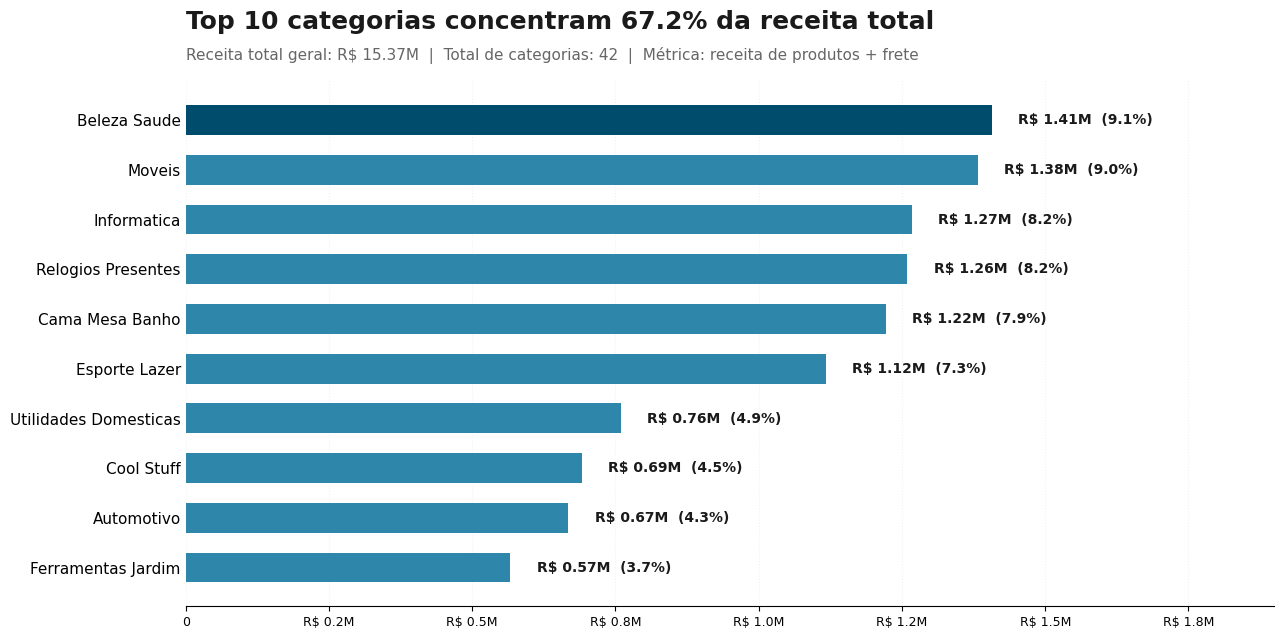

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import pandas as pd

# --- Preparação dos Dados ---
# Calcula os totais GERAIS antes de filtrar o Top 10 para o share ficar correto
receita_total_geral = tabela_receita_por_categoria['receita_total'].sum()
n_categorias        = tabela_receita_por_categoria['product_category_clean'].nunique()

# Pega o Top 10
tabela_top10 = tabela_receita_por_categoria.sort_values('receita_total', ascending=False).head(10).copy()
tabela_top10 = tabela_top10.sort_values('receita_total', ascending=True)  # invertido para barras horizontais

# Formata os nomes das categorias
tabela_top10['categoria_label'] = (
    tabela_top10['product_category_clean']
    .str.replace('_', ' ')
    .str.title()
)

# Métricas do Top 10
top10_share = tabela_top10['receita_total'].sum() / receita_total_geral * 100

# --- Configurações Visuais ---
AZUL_ESCURO, CINZA_TEXTO = '#004c6d', '#1A1A1A'
CINZA_SUB, AZUL_CLARO    = '#666666', '#2e86ab'

# ✅ ATUALIZADO: 9 barras com azul claro e 1 com azul escuro (a primeira colocada)
cores = [AZUL_CLARO] * 9 + [AZUL_ESCURO]

fig, ax = plt.subplots(figsize=(16, 7), dpi=100)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.xaxis.grid(True, linestyle=':', alpha=0.25, color='#cccccc')
ax.set_axisbelow(True)

# --- BARRAS HORIZONTAIS ---
bars = ax.barh(
    tabela_top10['categoria_label'],
    tabela_top10['receita_total'],
    color=cores,
    height=0.6,
    zorder=3
)

# --- RÓTULOS NAS BARRAS ---
for bar, (_, row) in zip(bars, tabela_top10.iterrows()):
    valor  = row['receita_total']
    share  = valor / receita_total_geral * 100
    ax.text(
        valor + receita_total_geral * 0.003,
        bar.get_y() + bar.get_height() / 2,
        f'R$ {valor/1e6:.2f}M  ({share:.1f}%)',
        va='center', ha='left', fontsize=10,
        color=CINZA_TEXTO, fontweight='bold'
    )

# --- FORMATAÇÃO DOS EIXOS ---
ax.xaxis.set_major_formatter(FuncFormatter(
    lambda x, p: f'R$ {x/1e6:.1f}M' if x > 0 else '0'
))
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=9)
ax.yaxis.set_tick_params(length=0)

ax.set_xlim(0, tabela_top10['receita_total'].max() * 1.35)

# --- TÍTULOS ---
# ✅ ATUALIZADO: Texto indicando Top 10
ax.text(0, 1.10,
        f'Top 10 categorias concentram {top10_share:.1f}% da receita total',
        transform=ax.transAxes, fontsize=18, fontweight='bold',
        color=CINZA_TEXTO, ha='left')

ax.text(0, 1.04,
        f'Receita total geral: R$ {receita_total_geral/1e6:.2f}M  |  '
        f'Total de categorias: {n_categorias}  |  '
        f'Métrica: receita de produtos + frete',
        transform=ax.transAxes, fontsize=11, color=CINZA_SUB, ha='left')

plt.subplots_adjust(top=0.85, bottom=0.10, left=0.22)
plt.show()

In [11]:
# --- KPI 4: Receita por Estado ---

# 1. Base usada nos indicadores anteriores de Receita

# 2. Tratamos categorias ausentes (Data Cleaning dentro do KPI)

# Usaremos 'product_category_name_english' que é o nome comum após a tradução
col_categoria = 'customer_state'

if col_categoria in df_receita.columns:
    df_receita[col_categoria] = df_receita[col_categoria].fillna('sem_preenchimento')
else:

    col_categoria = 'customer_state'


# 3. Agregamos os valores por categoria
# Como a base é consolidada por pedido, price e freight_value já são os totais do pedido
tabela_receita_por_estado = (
    df_receita
    .groupby(col_categoria, as_index=False)
    .agg(
        receita_produtos=('price', 'sum'),
        receita_frete=('freight_value', 'sum'),
        qtd_pedidos=('order_id', 'count') # Cada linha é um pedido único
    )
    .assign(receita_total=lambda x: x['receita_produtos'] + x['receita_frete'])
    .sort_values('receita_produtos', ascending=False)
    .reset_index(drop=True)
)

# --- RESULTADOS ---
print(f"{'='*20} KPI 4: RECEITA POR ESTADO {'='*20}")
print(f"Total de Estados Analisados: {tabela_receita_por_estado[col_categoria].nunique()}")
print(f"Receita da categoria 'sem_categoria': R$ {tabela_receita_por_estado.loc[tabela_receita_por_estado[col_categoria]=='sem_preenchimento', 'receita_total'].sum():,.2f}")
print(f"{'='*60}")

tabela_receita_por_estado.head(15)

==================== KPI 4: RECEITA POR ESTADO ====================
Total de Estados Analisados: 27
Receita da categoria 'sem_categoria': R$ 0.00


,customer_state,receita_produtos,receita_frete,qtd_pedidos,receita_total
0,SP,5055587.13,700412.63,40406,5755999.76
1,RJ,1751433.85,294923.79,12310,2046357.64
2,MG,1548206.88,265747.39,11319,1813954.27
3,RS,726373.92,132200.76,5328,858574.68
4,PR,664048.00,115166.08,4903,779214.08
5,SC,504774.07,87852.99,3537,592627.06
6,BA,493339.26,97477.54,3253,590816.80
7,DF,295454.64,49468.60,2074,344923.24
8,GO,281932.21,51224.02,1950,333156.23
9,ES,267783.66,48882.46,1992,316666.12


/tmp/ipykernel_2003/4280396062.py:82: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/tmp/ipykernel_2003/4280396062.py:82: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/tmp/ipykernel_2003/4280396062.py:82: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/tmp/ipykernel_2003/4280396062.py:82: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/tmp/ipykernel_2003/4280396062.py:82: UserWarning:

Geometry is in a geographic CRS. Results from 'c

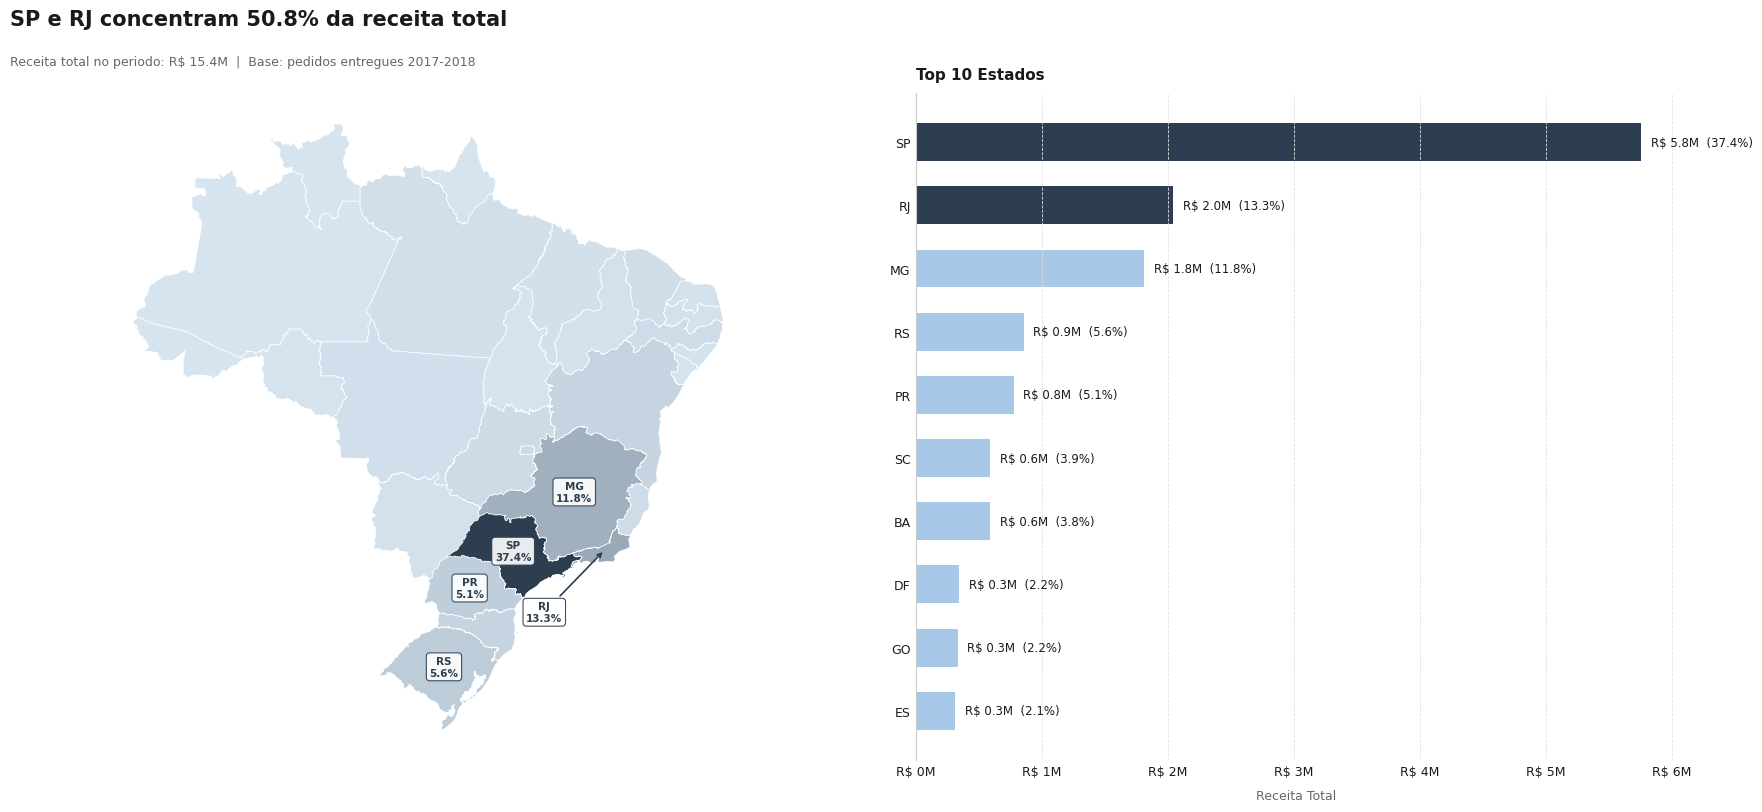

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import geopandas as gpd
import requests
import io

# ── Paleta ────────────────────────────────────────────────────────────────────
AZUL_ESCURO = '#2c3e50'
AZUL_CLARO  = '#a8c8e8'
CINZA_TEXTO = '#1A1A1A'
CINZA_SUB   = '#666666'
COR_PICO    = '#1b4f72'
LARANJA     = '#ff7f0e'

# ── Baixa o shapefile do Brasil por estado ────────────────────────────────────
url = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'
response = requests.get(url)
gdf = gpd.read_file(io.BytesIO(response.content))

gdf = gdf.rename(columns={'sigla': 'customer_state'})

# ── Merge com a tabela de receita ─────────────────────────────────────────────
gdf_merged = gdf.merge(tabela_receita_por_estado[['customer_state', 'receita_total']],
                        on='customer_state', how='left')
gdf_merged['receita_total'] = gdf_merged['receita_total'].fillna(0)

# ── Insight para o título ─────────────────────────────────────────────────────
receita_total_geral = tabela_receita_por_estado['receita_total'].sum()
top2 = tabela_receita_por_estado.head(2)
top2_receita = top2['receita_total'].sum()
top2_pct = (top2_receita / receita_total_geral) * 100
top2_estados = ' e '.join(top2['customer_state'].tolist())

# ── Top 10 para o bar chart ───────────────────────────────────────────────────
df_top10 = tabela_receita_por_estado.head(10).sort_values('receita_total', ascending=True)

# ── Canvas: Mapa + Bar Chart ──────────────────────────────────────────────────
fig, (ax_mapa, ax_bar) = plt.subplots(
    1, 2,
    figsize=(18, 8),
    gridspec_kw={'width_ratios': [1.2, 1]}
)
fig.patch.set_facecolor('white')

# ────────────────────────────────────────────────────────────────────────────
# MAPA
# ────────────────────────────────────────────────────────────────────────────
ax_mapa.set_facecolor('white')

cmap = mcolors.LinearSegmentedColormap.from_list(
    'azul_gradiente', ['#d6e4f0', AZUL_ESCURO]
)

gdf_merged.plot(
    column='receita_total',
    cmap=cmap,
    linewidth=0.5,
    edgecolor='white',
    ax=ax_mapa,
    legend=False,
)

# Anotação dos Top 5 estados no mapa
# Anotação dos Top 5 estados no mapa
top5 = tabela_receita_por_estado.head(5)

# Offsets customizados para estados pequenos
offsets = {
    'SP': (0, 0),
    'RJ': (-4, -4),   # 👈 empurra a anotação para fora
    'MG': (0, 0),
    'RS': (0, 0),
    'PR': (0, 0),
}

for _, row in top5.iterrows():
    estado = row['customer_state']
    pct = (row['receita_total'] / receita_total_geral) * 100
    geo_row = gdf_merged[gdf_merged['customer_state'] == estado]
    if not geo_row.empty:
        centroid = geo_row.geometry.centroid.iloc[0]
        ox, oy = offsets.get(estado, (0, 0))

        ax_mapa.annotate(
            f"{estado}\n{pct:.1f}%",
            xy=(centroid.x, centroid.y),
            xytext=(centroid.x + ox, centroid.y + oy),
            ha='center', va='center',
            fontsize=7.5,
            fontweight='bold',
            color=AZUL_ESCURO,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=AZUL_ESCURO, lw=0.8, alpha=0.9),
            arrowprops=dict(arrowstyle='->', color=AZUL_ESCURO, lw=1.2),
        )


ax_mapa.set_axis_off()

# ────────────────────────────────────────────────────────────────────────────
# BAR CHART HORIZONTAL — Top 10
# ────────────────────────────────────────────────────────────────────────────
ax_bar.set_facecolor('white')

cores_bar = [AZUL_ESCURO if i >= len(df_top10) - 2 else AZUL_CLARO
             for i in range(len(df_top10))]

bars = ax_bar.barh(
    df_top10['customer_state'],
    df_top10['receita_total'],
    color=cores_bar,
    edgecolor='none',
    height=0.6,
)

# Rótulo de valor nas barras
# Rótulo de valor e percentual nas barras
for bar, val in zip(bars, df_top10['receita_total']):
    pct = (val / receita_total_geral) * 100
    ax_bar.text(
        bar.get_width() + receita_total_geral * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'R$ {val/1e6:.1f}M  ({pct:.1f}%)',
        va='center',
        fontsize=8.5,
        color=CINZA_TEXTO,
    )

ax_bar.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.0f}M'))
ax_bar.tick_params(axis='both', length=0, labelsize=9, colors=CINZA_TEXTO)
ax_bar.spines[['top', 'right', 'bottom']].set_visible(False)
ax_bar.spines['left'].set_color('#cccccc')
ax_bar.xaxis.grid(True, linestyle='--', linewidth=0.6, color='#e0e0e0')
ax_bar.yaxis.grid(False)
ax_bar.set_xlabel('Receita Total', fontsize=9, color=CINZA_SUB, labelpad=8)
ax_bar.set_title('Top 10 Estados', fontsize=11, fontweight='bold',
                  color=CINZA_TEXTO, loc='left', pad=10)

# ── Título principal orientado a insight ─────────────────────────────────────
fig.suptitle(
    f'{top2_estados} concentram {top2_pct:.1f}% da receita total',
    fontsize=15,
    fontweight='bold',
    color=CINZA_TEXTO,
    x=0.02,
    ha='left',
    y=1.01,
)
fig.text(
    0.02, 0.94,
    f'Receita total no periodo: R$ {receita_total_geral/1e6:.1f}M  |  Base: pedidos entregues 2017-2018',
    fontsize=9,
    color=CINZA_SUB,
    ha='left',
)

plt.tight_layout()
plt.savefig('receita_por_estado.png', dpi=150, bbox_inches='tight')
plt.show()